# IoT Sensor Data Analytics Project
Hi! In this notebook, I'll be walking through the data analysis of four different IoT sensors. We have data from:
1. Gas Sensors (MQ series)
2. Ultrasonic Sensors
3. Temperature & Humidity Sensors
4. Earthquake (Vibration) Sensors

My goal here is to clean the data, explore the trends, find any hidden correlations, and detect anomalies. Let's get started by importing the libraries we'll need.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

# Make our plots look nice
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)


## 1. Data Cleaning
First things first, let's load up the datasets. I've placed them in the `dataset/` folder.

**Note:** The Temperature/Humidity sensor CSV does not have headers and contains raw string formats like `T=22.0`. I will clean that up right as we load it!


In [2]:
df_gas = pd.read_csv("dataset/gas_sensor.csv")
df_ultra = pd.read_csv("dataset/ultrasonic_sensor.csv")
df_earth = pd.read_csv("dataset/earthquake_sensor.csv")

# Load Temperature & Humidity data
# It has no headers, so we name the columns manually
df_th = pd.read_csv("dataset/temp_hum_sensor.csv", names=['date', 'time', 'temperature', 'humidity'])

# Clean up 'T=' and 'H=' from the values
df_th['temperature'] = df_th['temperature'].str.replace('T=', '', regex=False)
df_th['humidity'] = df_th['humidity'].str.replace('H=', '', regex=False)

# Some rows have 'error' instead of data, so we convert them to numeric, turning errors into NaNs
df_th['temperature'] = pd.to_numeric(df_th['temperature'], errors='coerce')
df_th['humidity'] = pd.to_numeric(df_th['humidity'], errors='coerce')


Let's take a quick look at the shapes and columns of these datasets to understand what we're working with.


In [3]:
dfs = {
    "Gas Sensor": df_gas,
    "Ultrasonic Sensor": df_ultra,
    "Temp/Hum Sensor": df_th,
    "Earthquake Sensor": df_earth
}

for name, df in dfs.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")


Gas Sensor: 6400 rows, 10 columns
Ultrasonic Sensor: 549 rows, 3 columns
Temp/Hum Sensor: 336 rows, 4 columns
Earthquake Sensor: 30000 rows, 3 columns


Now I'm going to check if there are any missing values or duplicate records in our data. It's super common in IoT for packets to drop or duplicate.


In [4]:
for name, df in dfs.items():
    missing = df.isnull().sum().sum()
    dupes = df.duplicated().sum()
    print(f"{name} -> Missing: {missing}, Duplicates: {dupes}")


Gas Sensor -> Missing: 0, Duplicates: 0
Ultrasonic Sensor -> Missing: 0, Duplicates: 5
Temp/Hum Sensor -> Missing: 32, Duplicates: 0
Earthquake Sensor -> Missing: 0, Duplicates: 373


Let's go ahead and clean that up. I'll drop the duplicate rows and any rows that have missing values so we have a solid foundation for analysis.


In [5]:
for name, df in dfs.items():
    if df.duplicated().sum() > 0:
        df.drop_duplicates(inplace=True)
    if df.isnull().sum().sum() > 0:
        df.dropna(inplace=True)
        
print("Data cleaning complete!")


Data cleaning complete!


## 2. Temperature Analysis
Let's dive into the Temperature data. I want to see the basic statistics first.


In [6]:
display(df_th['temperature'].describe())


count    320.000000
mean      21.353125
std        5.047454
min        9.000000
25%       18.000000
50%       20.000000
75%       23.000000
max       37.000000
Name: temperature, dtype: float64

Here are the exact measures of central tendency for temperature:


In [7]:
print(f"Mean: {df_th['temperature'].mean():.2f} °C")
print(f"Median: {df_th['temperature'].median():.2f} °C")
print(f"Mode: {df_th['temperature'].mode().iloc[0]:.2f} °C")


Mean: 21.35 °C
Median: 20.00 °C
Mode: 21.00 °C


A histogram will give us a good visual of how the temperature readings are distributed.


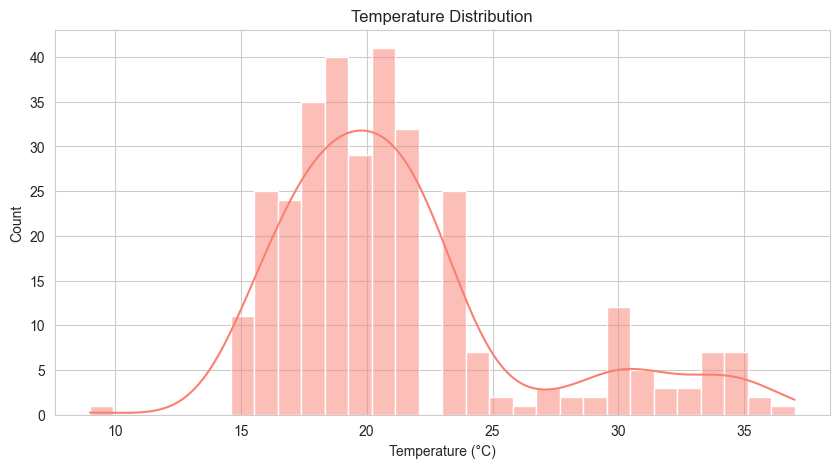

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df_th['temperature'], bins=30, kde=True, color='salmon')
plt.title('Temperature Distribution')
plt.xlabel('Temperature (°C)')
plt.show()


And a boxplot will help us easily spot if there are any crazy outliers.


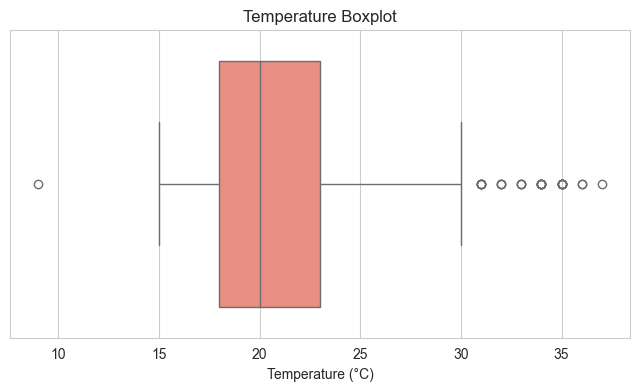

In [9]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_th['temperature'], color='salmon')
plt.title('Temperature Boxplot')
plt.xlabel('Temperature (°C)')
plt.show()


Let's see how the temperature fluctuates over time. I'll plot the raw data and add a rolling average line to make the trend clearer.


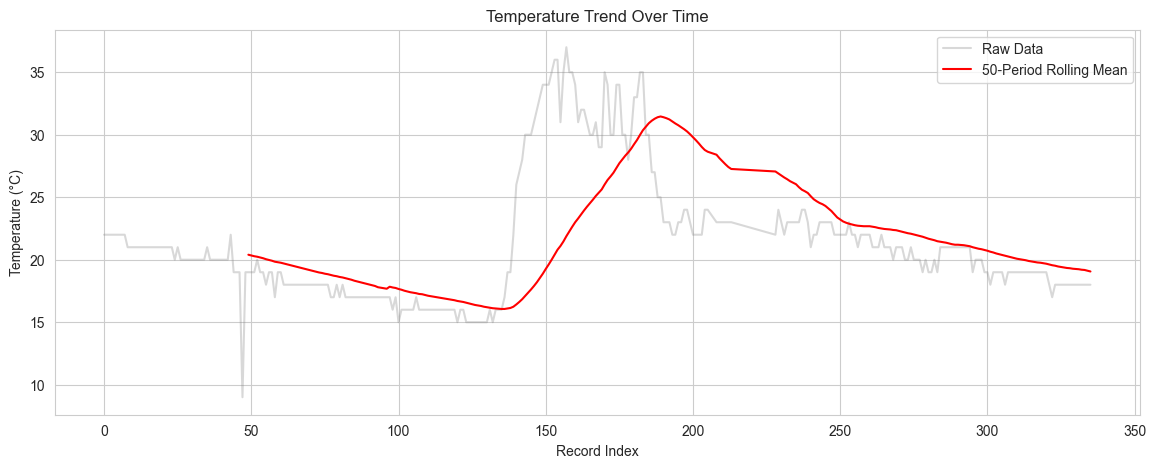

In [10]:
plt.figure(figsize=(14, 5))
# Using index for x-axis as a simple timeline
plt.plot(df_th.index, df_th['temperature'], alpha=0.3, label='Raw Data', color='gray')
plt.plot(df_th.index, df_th['temperature'].rolling(50).mean(), color='red', label='50-Period Rolling Mean')
plt.title('Temperature Trend Over Time')
plt.xlabel('Record Index')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()


## 3. Humidity Analysis
Now, let's look at the Humidity readings in the same way.


In [11]:
display(df_th['humidity'].describe())


count    320.000000
mean      21.865625
std        7.625486
min       12.000000
25%       20.000000
50%       21.000000
75%       23.250000
max      140.000000
Name: humidity, dtype: float64

Central tendency for humidity:


In [12]:
print(f"Mean: {df_th['humidity'].mean():.2f} %")
print(f"Median: {df_th['humidity'].median():.2f} %")
print(f"Mode: {df_th['humidity'].mode().iloc[0]:.2f} %")


Mean: 21.87 %
Median: 21.00 %
Mode: 21.00 %


Here is the distribution of the humidity data.


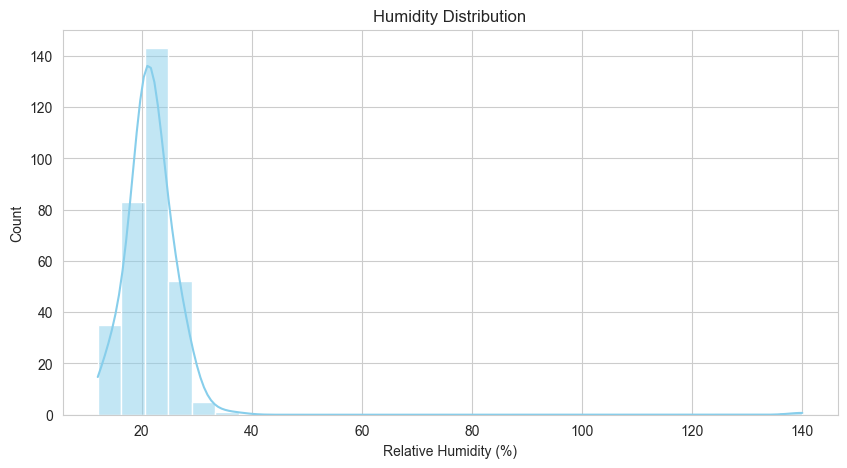

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df_th['humidity'], bins=30, kde=True, color='skyblue')
plt.title('Humidity Distribution')
plt.xlabel('Relative Humidity (%)')
plt.show()


Boxplot for humidity outliers:


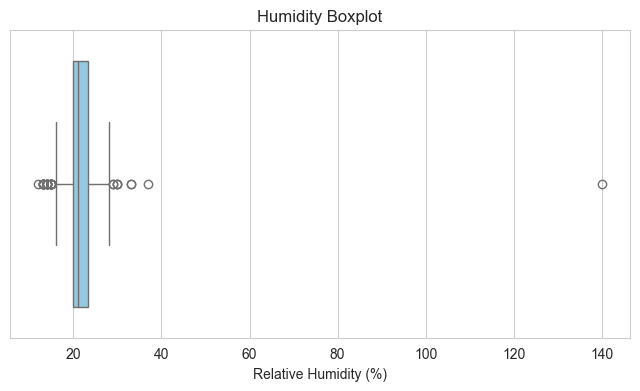

In [14]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_th['humidity'], color='skyblue')
plt.title('Humidity Boxplot')
plt.xlabel('Relative Humidity (%)')
plt.show()


And the time-series plot to see how humidity changed over the recording period.


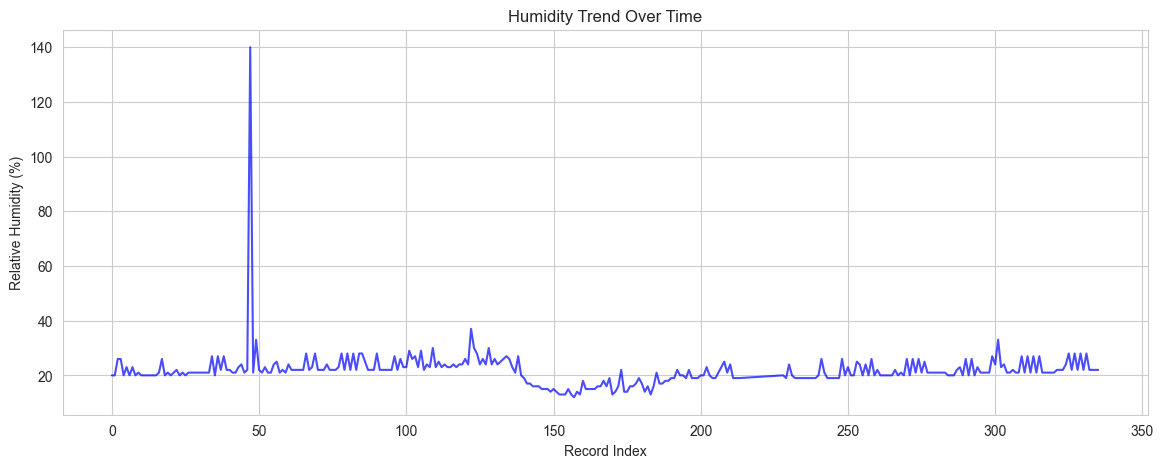

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(df_th.index, df_th['humidity'], color='blue', alpha=0.7)
plt.title('Humidity Trend Over Time')
plt.xlabel('Record Index')
plt.ylabel('Relative Humidity (%)')
plt.show()


## 4. Temperature vs Humidity Relationship
Usually, temperature and humidity are inversely related (as it gets hotter, relative humidity drops). Let's see if our data shows that by calculating the Pearson and Spearman correlations.


In [16]:
pearson = df_th['temperature'].corr(df_th['humidity'], method='pearson')
spearman = df_th['temperature'].corr(df_th['humidity'], method='spearman')

print(f"Pearson Correlation: {pearson:.4f}")
print(f"Spearman Correlation: {spearman:.4f}")


Pearson Correlation: -0.5037
Spearman Correlation: -0.7818


Let's visualize this relationship with a scatter plot and a regression line.


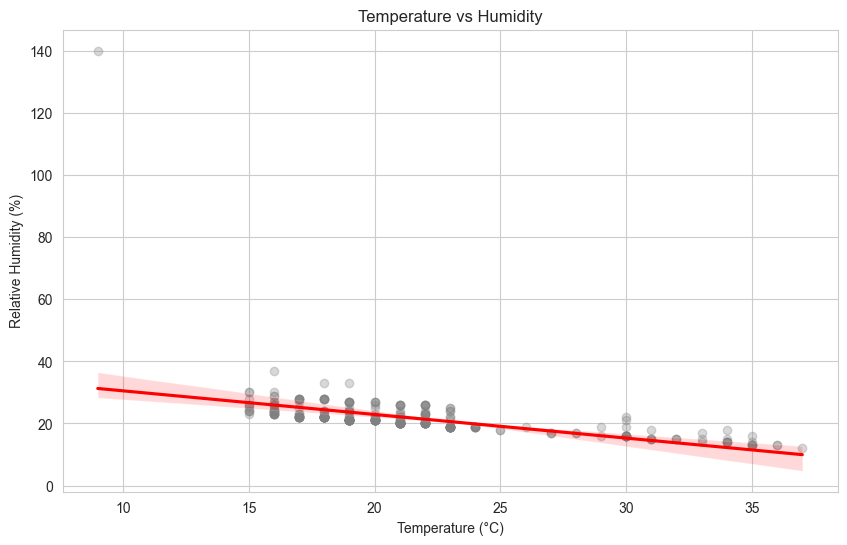

In [17]:
plt.figure(figsize=(10, 6))
sns.regplot(x='temperature', y='humidity', data=df_th, 
            scatter_kws={'alpha':0.3, 'color':'gray'}, 
            line_kws={'color':'red'})
plt.title('Temperature vs Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()


We can also view this via a correlation heatmap. It's a bit overkill for just two variables, but it's a great habit for data analysis!


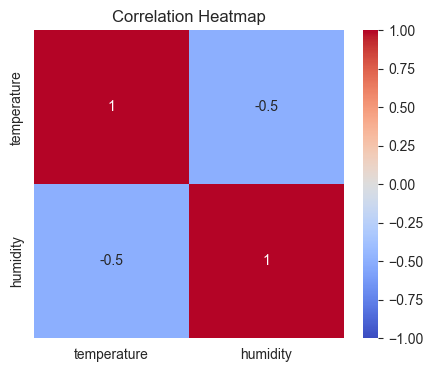

In [18]:
plt.figure(figsize=(5, 4))
sns.heatmap(df_th[['temperature', 'humidity']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()


## 5. Humidity Anomaly Detection
I'm going to use an `IsolationForest` model to automatically detect any weird spikes or drops in humidity that might indicate a sensor issue or environmental leak.


In [19]:
# Set up the model assuming about 5% of data might be anomalous
iso_forest_hum = IsolationForest(contamination=0.05, random_state=42)

# Predict anomalies
df_th['hum_anomaly'] = iso_forest_hum.fit_predict(df_th[['humidity']])

# Convert the output: 1 for anomaly, 0 for normal (makes it easier to read)
df_th['hum_anomaly'] = df_th['hum_anomaly'].map({1: 0, -1: 1}) 

anomaly_count = df_th['hum_anomaly'].sum()
anomaly_pct = (anomaly_count / len(df_th)) * 100
print(f"Found {anomaly_count} anomalous humidity readings ({anomaly_pct:.2f}% of data).")


Found 10 anomalous humidity readings (3.12% of data).


Let's plot these anomalies on our timeline so we can see exactly when they happened.


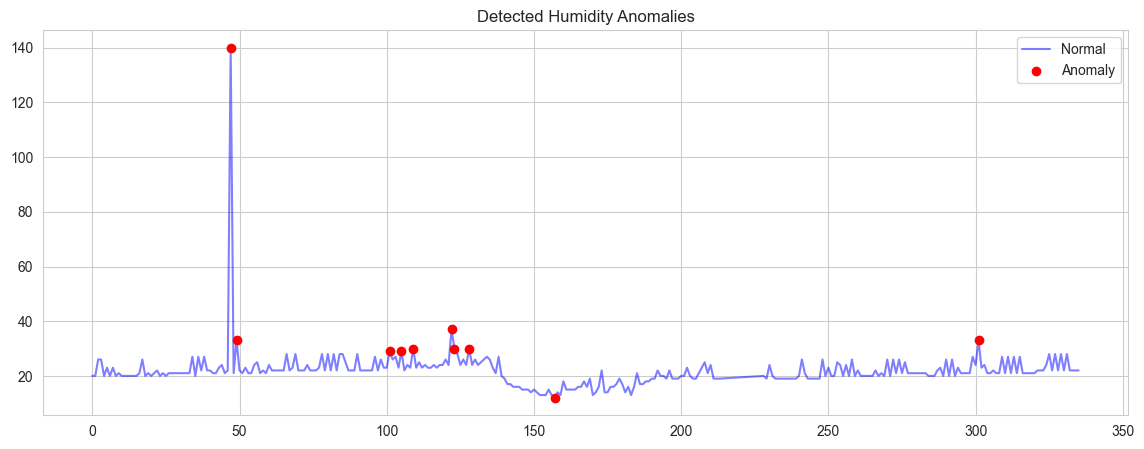

In [20]:
plt.figure(figsize=(14, 5))
plt.plot(df_th.index, df_th['humidity'], color='blue', alpha=0.5, label='Normal')
plt.scatter(df_th.index[df_th['hum_anomaly'] == 1], 
            df_th['humidity'][df_th['hum_anomaly'] == 1], 
            color='red', label='Anomaly', zorder=5)
plt.title('Detected Humidity Anomalies')
plt.legend()
plt.show()


## 6. Temperature Anomaly Detection
Let's do the exact same thing for the Temperature data. Sudden spikes in temperature are definitely something we want to flag.


In [21]:
iso_forest_temp = IsolationForest(contamination=0.05, random_state=42)
df_th['temp_anomaly'] = iso_forest_temp.fit_predict(df_th[['temperature']])
df_th['temp_anomaly'] = df_th['temp_anomaly'].map({1: 0, -1: 1})

temp_anomaly_count = df_th['temp_anomaly'].sum()
temp_anomaly_pct = (temp_anomaly_count / len(df_th)) * 100
print(f"Found {temp_anomaly_count} anomalous temperature readings ({temp_anomaly_pct:.2f}% of data).\n")

# Threshold classification helper functions
def classify_temp(t):
    if t < 9.0 or t > 28.0:
        return 'Danger'
    elif (9.0 <= t < 18.0) or (23.0 < t <= 28.0):
        return 'Warning'
    else:
        return 'Safe'

def classify_hum(h):
    if h < 12.0 or h > 40.0:
        return 'Danger'
    elif (12.0 <= h < 20.0) or (23.25 < h <= 40.0):
        return 'Warning'
    else:
        return 'Safe'

def classify_env_combined(row):
    t_status = classify_temp(row['temperature'])
    h_status = classify_hum(row['humidity'])
    if t_status == 'Danger' or h_status == 'Danger':
        return 'Danger'
    elif t_status == 'Warning' or h_status == 'Warning':
        return 'Warning'
    else:
        return 'Safe'

df_th['temp_status'] = df_th['temperature'].apply(classify_temp)
df_th['hum_status'] = df_th['humidity'].apply(classify_hum)
df_th['combined_status'] = df_th.apply(classify_env_combined, axis=1)

print("Temperature & Humidity Threshold Classification Breakdown:")
for status in ['Safe', 'Warning', 'Danger']:
    cnt_t = (df_th['temp_status'] == status).sum()
    cnt_h = (df_th['hum_status'] == status).sum()
    cnt_c = (df_th['combined_status'] == status).sum()
    print(f" - {status:7s} -> Temp: {cnt_t:4d} | Hum: {cnt_h:4d} | Combined Env: {cnt_c:4d}")


Found 15 anomalous temperature readings (4.69% of data).

Temperature & Humidity Threshold Classification Breakdown:
 - Safe    -> Temp:  202 | Hum:  167 | Combined Env:  141
 - Warning -> Temp:   76 | Hum:  152 | Combined Env:  136
 - Danger  -> Temp:   42 | Hum:    1 | Combined Env:   43


Visualizing the temperature anomalies:


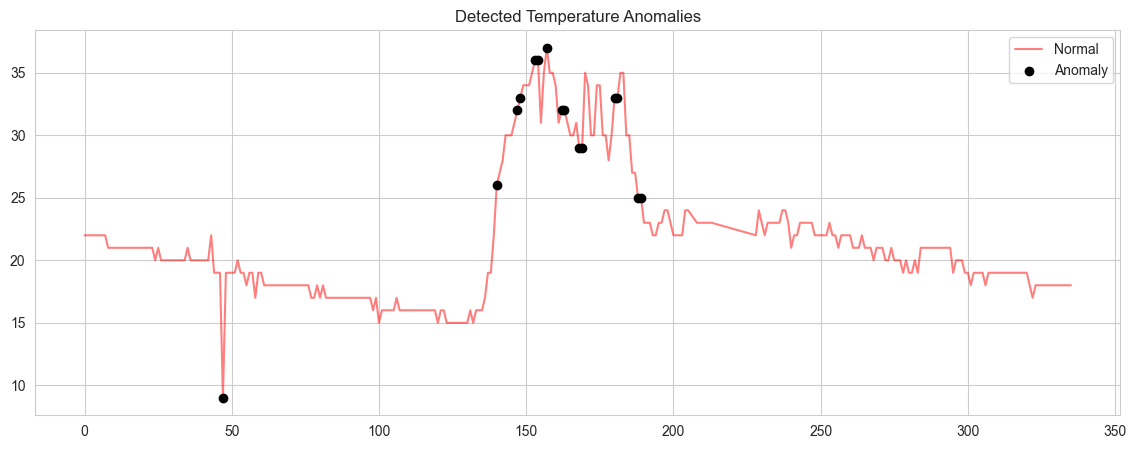

In [22]:
plt.figure(figsize=(14, 5))
plt.plot(df_th.index, df_th['temperature'], color='red', alpha=0.5, label='Normal')
plt.scatter(df_th.index[df_th['temp_anomaly'] == 1], 
            df_th['temperature'][df_th['temp_anomaly'] == 1], 
            color='black', label='Anomaly', zorder=5)
plt.title('Detected Temperature Anomalies')
plt.legend()
plt.show()


## 7. Gas Sensor Analysis
Moving on to the Gas dataset! We have readings from various MQ sensors. Let's see what gases they detected.


In [23]:
display(df_gas.head())
print("\nDistribution of Gas Types detected:")
print(df_gas['Gas'].value_counts())


,Serial Number,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135,Gas,Corresponding Image Name
0,0,555,515,377,338,666,451,416,NoGas,0_NoGas
1,1,555,516,377,339,666,451,416,NoGas,1_NoGas
2,2,556,517,376,337,666,451,416,NoGas,2_NoGas
3,3,556,516,376,336,665,451,416,NoGas,3_NoGas
4,4,556,516,376,337,665,451,416,NoGas,4_NoGas



Distribution of Gas Types detected:
Gas
NoGas      1600
Perfume    1600
Smoke      1600
Mixture    1600
Name: count, dtype: int64


I want to see how each sensor reacts on average to the different gases.


In [24]:
sensor_cols = [c for c in df_gas.columns if 'MQ' in c]
display(df_gas.groupby('Gas')[sensor_cols].mean())

def classify_gas_sensor(val):
    if val < 450.0:
        return 'Danger'
    elif 450.0 <= val <= 600.0:
        return 'Warning'
    else:
        return 'Safe'

def classify_gas_combined(row, cols):
    statuses = [classify_gas_sensor(row[col]) for col in cols]
    if 'Danger' in statuses:
        return 'Danger'
    elif 'Warning' in statuses:
        return 'Warning'
    else:
        return 'Safe'

for col in sensor_cols:
    df_gas[f'{col}_status'] = df_gas[col].apply(classify_gas_sensor)
df_gas['combined_status'] = df_gas.apply(lambda r: classify_gas_combined(r, sensor_cols), axis=1)

print("\nMQ Gas Sensors Combined Safety Status Breakdown:")
for status in ['Safe', 'Warning', 'Danger']:
    cnt = (df_gas['combined_status'] == status).sum()
    pct = (cnt / len(df_gas)) * 100
    print(f" - {status:7s} -> {cnt:4d} readings ({pct:.2f}%)")


,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135
Gas,,,,,,,
Mixture,593.400625,419.058125,407.490625,376.472500,460.115625,315.252500,403.390625
NoGas,748.391875,528.935000,430.721250,425.383750,606.275625,637.147500,474.467500
Perfume,745.330625,527.711875,439.887500,429.009375,617.203125,633.794375,480.941875
Smoke,623.250625,372.393750,340.216875,368.169375,580.213750,583.700625,308.108125



MQ Gas Sensors Combined Safety Status Breakdown:
 - Safe    ->    0 readings (0.00%)
 - Warning -> 1041 readings (16.27%)
 - Danger  -> 5359 readings (83.73%)


Let's visualize the spread of readings for the first few sensors based on the gas type using boxplots.


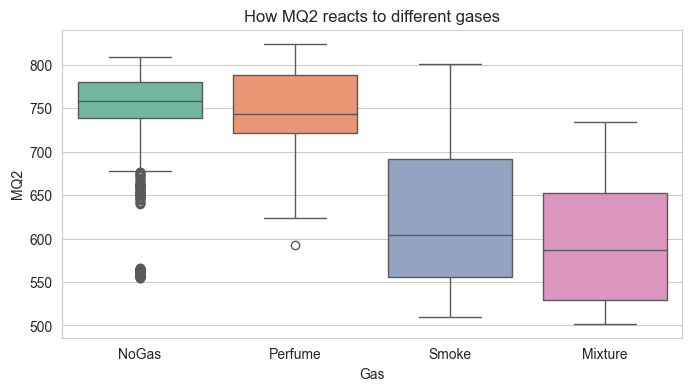

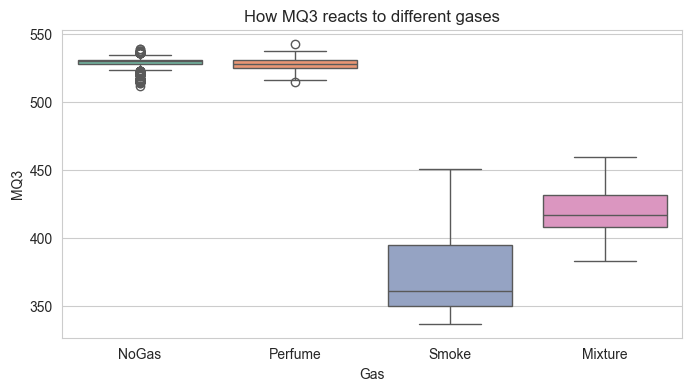

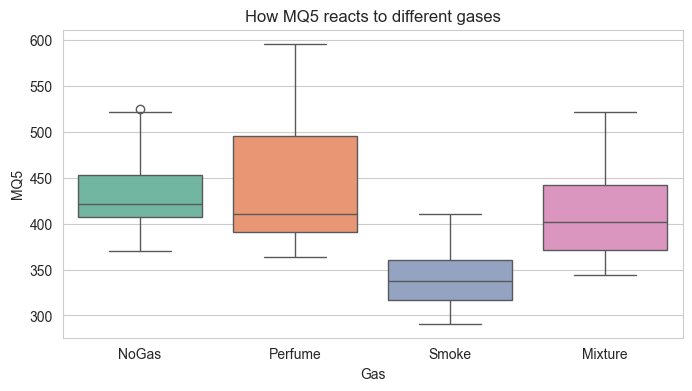

In [25]:
for col in sensor_cols[:3]: 
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Gas', y=col, data=df_gas, hue='Gas', palette='Set2', legend=False)
    plt.title(f'How {col} reacts to different gases')
    plt.show()


Since we have so many sensors, I wonder if they overlap in what they detect. A correlation heatmap will tell us if some sensors are essentially giving us the same information.


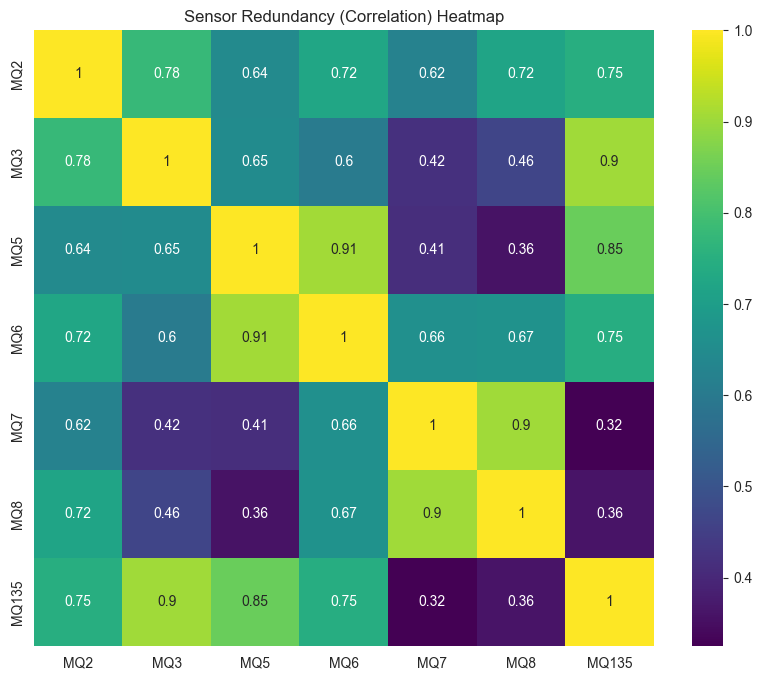

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_gas[sensor_cols].corr(), annot=True, cmap='viridis')
plt.title('Sensor Redundancy (Correlation) Heatmap')
plt.show()


*Insight: High correlation blocks mean several MQ sensors react almost identically. We could probably reduce hardware costs by dropping redundant sensors!*


## 8. Ultrasonic Sensor Analysis
Next up is the Ultrasonic sensor. This one measures distance and speed, and assigns a risk status.


In [27]:
display(df_ultra.head())
print("\nHow often do we see each status?")
print(df_ultra['status'].value_counts())


,distance,speed,status
0,40.6,4.8,0
1,74.5,3.0,0
2,19.8,17.3,2
3,10.5,28.0,2
4,62.1,3.5,0



How often do we see each status?
status
0    315
1    116
2    113
Name: count, dtype: int64


Let's look at the average distance and speed for each safety status.


In [28]:
display(df_ultra.groupby('status')[['distance', 'speed']].mean())

def classify_ultrasonic(row):
    dist = row['distance']
    speed = row['speed']
    if dist < 20.0 or speed > 15.0:
        return 'Danger'
    elif dist > 50.0 and speed < 5.0:
        return 'Safe'
    else:
        return 'Warning'

df_ultra['calculated_status'] = df_ultra.apply(classify_ultrasonic, axis=1)

print("\nUltrasonic Proximity Calculated Status Breakdown:")
for status, label in [('Safe', 'Clear (Status 0)'), ('Warning', 'Warning (Status 1)'), ('Danger', 'Danger (Status 2)')]:
    cnt = (df_ultra['calculated_status'] == status).sum()
    pct = (cnt / len(df_ultra)) * 100
    print(f" - {label:20s} -> {cnt:4d} events ({pct:.2f}%)")


,distance,speed
status,,
0,70.820635,2.566032
1,30.039655,9.915517
2,12.715044,22.992035



Ultrasonic Proximity Calculated Status Breakdown:
 - Clear (Status 0)     ->  261 events (47.98%)
 - Warning (Status 1)   ->  170 events (31.25%)
 - Danger (Status 2)    ->  113 events (20.77%)


A scatter plot is perfect here to see the actual boundaries where "Clear" turns into "Warning" and then into "Danger".


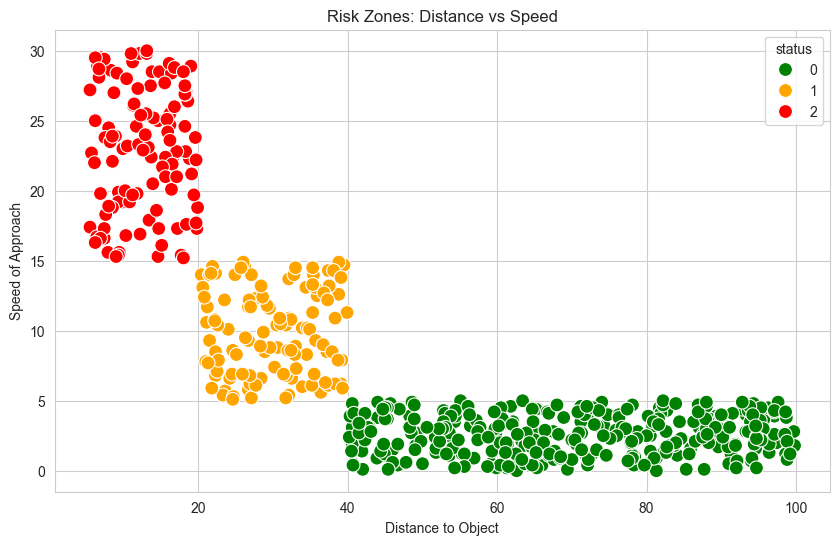

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance', y='speed', hue='status', data=df_ultra, palette={0:'green', 1:'orange', 2:'red'}, s=100)
plt.title('Risk Zones: Distance vs Speed')
plt.xlabel('Distance to Object')
plt.ylabel('Speed of Approach')
plt.show()


*Insight: Distance is the primary factor. As objects get closer (moving left on the X-axis), the status quickly escalates to Danger, regardless of the speed.*


## 9. Earthquake (Vibration) Sensor Analysis
Finally, let's look at the earthquake data. We have X, Y, and Z vibration vectors. I'm going to combine them into a single "magnitude" feature using the Euclidean norm.


In [30]:
# Calculate overall magnitude
df_earth['magnitude'] = np.sqrt(df_earth['X']**2 + df_earth['Y']**2 + df_earth['Z']**2)

display(df_earth[['X', 'Y', 'Z', 'magnitude']].head())

def classify_earthquake(row):
    mag = row['magnitude']
    if mag < 6.0 or mag > 15.0:
        return 'Danger'
    elif 6.0 <= mag <= 12.0:
        return 'Safe'
    else:
        return 'Warning'

df_earth['status'] = df_earth.apply(classify_earthquake, axis=1)

print("\nEarthquake Vibration Activity Breakdown:")
for status in ['Safe', 'Warning', 'Danger']:
    cnt = (df_earth['status'] == status).sum()
    pct = (cnt / len(df_earth)) * 100
    print(f" - {status:7s} -> {cnt:5d} readings ({pct:.2f}%)")


,X,Y,Z,magnitude
0,0.00,0.00,0.00,0.000000
1,9.20,1.67,1.84,9.529664
2,8.90,1.66,1.58,9.190321
3,8.96,1.78,1.65,9.282914
4,9.18,1.67,1.89,9.520158



Earthquake Vibration Activity Breakdown:
 - Safe    -> 28805 readings (97.23%)
 - Warning ->   790 readings (2.67%)
 - Danger  ->    32 readings (0.11%)


Let's plot this new magnitude feature over time to see the baseline vibration and any major spikes (earthquakes).


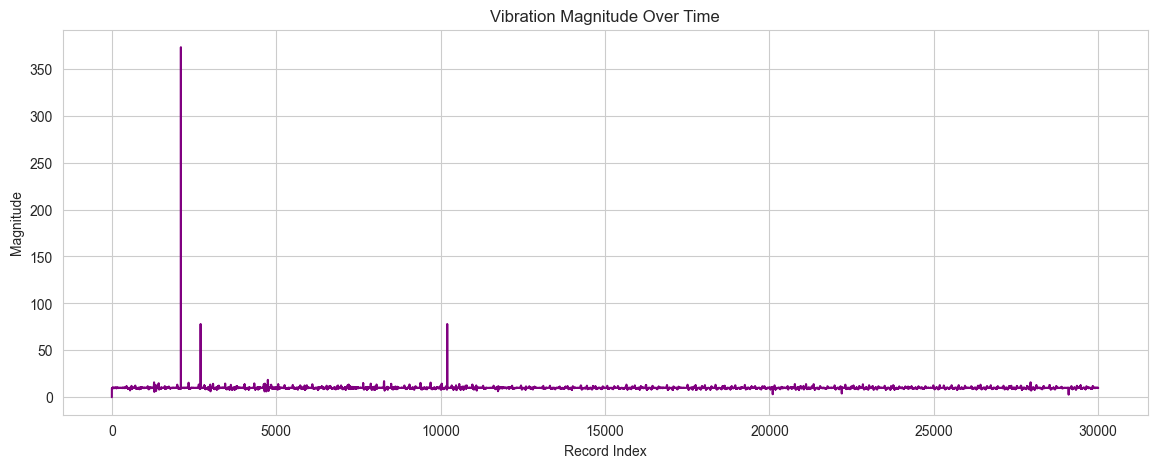

In [31]:
plt.figure(figsize=(14, 5))
plt.plot(df_earth.index, df_earth['magnitude'], color='purple')
plt.title('Vibration Magnitude Over Time')
plt.xlabel('Record Index')
plt.ylabel('Magnitude')
plt.show()


We can also break it down axis by axis to see exactly which direction the vibration is coming from.


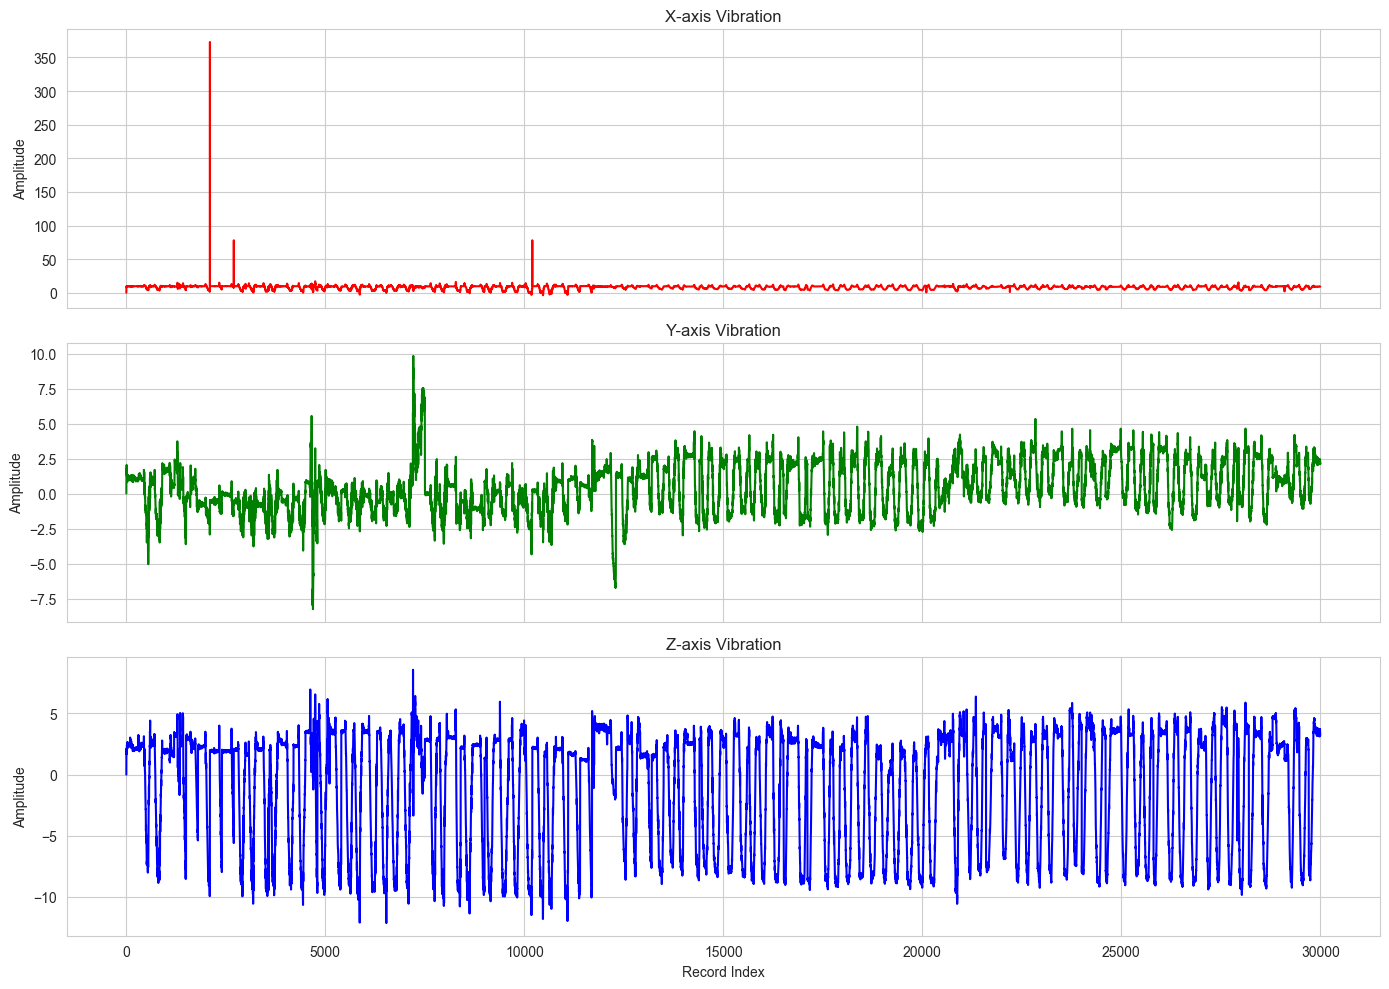

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
colors = ['red', 'green', 'blue']
axes_names = ['X', 'Y', 'Z']

for i in range(3):
    axes[i].plot(df_earth[axes_names[i]], color=colors[i])
    axes[i].set_title(f'{axes_names[i]}-axis Vibration')
    axes[i].set_ylabel('Amplitude')

plt.xlabel('Record Index')
plt.tight_layout()
plt.show()


## 10. Final Summary Dashboard
We've processed a lot of data! Let's pull the most important metrics together into a final summary.


In [33]:
print("="*65)
print("                    EXECUTIVE KPI DASHBOARD                     ")
print("="*65)

print(f"[1] Temp / Hum Sensor")
print(f"    - Average Temperature:     {df_th['temperature'].mean():.2f} °C")
print(f"    - Temperature Anomalies:   {temp_anomaly_count} flags")
print(f"    - Average Humidity:        {df_th['humidity'].mean():.2f} %")
print(f"    - Humidity Anomalies:      {anomaly_count} flags")
print(f"    - Safe / Warning / Danger: {sum(df_th['combined_status']=='Safe')} / {sum(df_th['combined_status']=='Warning')} / {sum(df_th['combined_status']=='Danger')}\n")

print(f"[2] Gas Sensor")
print(f"    - Most Detected Gas:       {df_gas['Gas'].mode()[0]}")
print(f"    - Safe / Warning / Danger: {sum(df_gas['combined_status']=='Safe')} / {sum(df_gas['combined_status']=='Warning')} / {sum(df_gas['combined_status']=='Danger')}\n")

print(f"[3] Ultrasonic Proximity")
print(f"    - Average Distance / Speed:{df_ultra['distance'].mean():.2f} cm / {df_ultra['speed'].mean():.2f} units/s")
print(f"    - Clear / Warn / Danger:   {sum(df_ultra['calculated_status']=='Safe')} / {sum(df_ultra['calculated_status']=='Warning')} / {sum(df_ultra['calculated_status']=='Danger')}\n")

print(f"[4] Earthquake Vibration")
max_mag = df_earth['magnitude'].max()
print(f"    - Max Vibration Spike:     {max_mag:.2f}")
print(f"    - Safe / Warning / Danger: {sum(df_earth['status']=='Safe')} / {sum(df_earth['status']=='Warning')} / {sum(df_earth['status']=='Danger')}\n")
print("="*65)


                    EXECUTIVE KPI DASHBOARD                     
[1] Temp / Hum Sensor
    - Average Temperature:     21.35 °C
    - Temperature Anomalies:   15 flags
    - Average Humidity:        21.87 %
    - Humidity Anomalies:      10 flags
    - Safe / Warning / Danger: 141 / 136 / 43

[2] Gas Sensor
    - Most Detected Gas:       Mixture
    - Safe / Warning / Danger: 0 / 1041 / 5359

[3] Ultrasonic Proximity
    - Average Distance / Speed:50.05 cm / 8.38 units/s
    - Clear / Warn / Danger:   261 / 170 / 113

[4] Earthquake Vibration
    - Max Vibration Spike:     373.01
    - Safe / Warning / Danger: 28805 / 790 / 32

